# Removel of Samples Flagged by Cleanlab

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from PIL import Image
from src.data import augment_embeddings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler


In [3]:
# View Summary 

summ= pd.read_csv("../../outputs/analysis/data_quality/data_quality_summary.csv")


print(f"Total samples analyzed: {summ['total_samples'][0]}")
print(f"Samples with potential issues: {summ['n_label_issues'][0]} ({summ['label_issue_rate'][0]*100:.4}%)")

Total samples analyzed: 8637
Samples with potential issues: 3695 (42.78%)


Lets create a few new variables that will help understand how to process the label issues. 

New variables: 

- give_label - suggested_label
- confidence_in_given -  confidence_in_suggested
- 

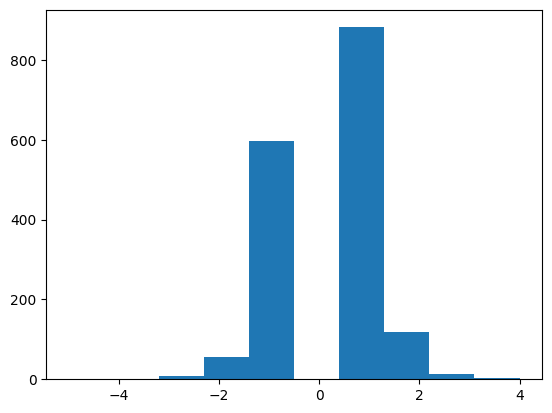

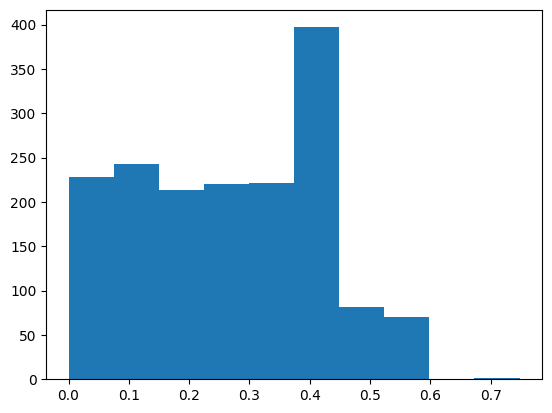

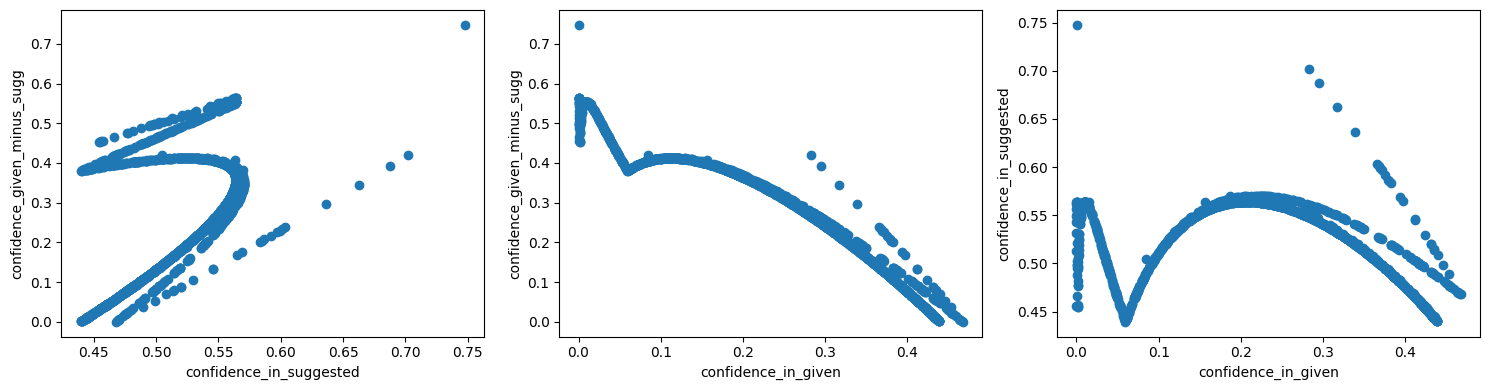

In [4]:
df = pd.read_csv("../../outputs/analysis/data_quality/label_issues.csv")
df.sort_values(by = "confidence_in_given", ascending = False)

# New Variables
df["confidence_given_minus_sugg"] = df["confidence_in_suggested"] - df["confidence_in_given"]
df["given_minus_sugg_label"] = df["suggested_label"] - df["given_label"]

df = df[df["given_minus_sugg_label"] != 0]


# Label Diff distribution
plt.hist(df["given_minus_sugg_label"])
plt.show()

# Confidence Diff distribution
plt.hist(df["confidence_given_minus_sugg"])
plt.show()

# Difference vs sugg and given confidence
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x=df["confidence_in_suggested"], y=df["confidence_given_minus_sugg"])
axes[0].set_xlabel("confidence_in_suggested")
axes[0].set_ylabel("confidence_given_minus_sugg")

axes[1].scatter(x=df["confidence_in_given"], y=df["confidence_given_minus_sugg"])
axes[1].set_xlabel("confidence_in_given")
axes[1].set_ylabel("confidence_given_minus_sugg")

axes[2].scatter(x=df["confidence_in_given"], y=df["confidence_in_suggested"])
axes[2].set_xlabel("confidence_in_given")
axes[2].set_ylabel("confidence_in_suggested")

plt.tight_layout()
plt.show()


In [37]:
df[df["confidence_in_suggested"] >= 0.5]

,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested,confidence_given_minus_sugg,given_minus_sugg_label
0,175,24409454,10,5,8.031457e-12,0.564128,0.564128,-5
1,2189,24601200,5,9,1.932301e-08,0.562265,0.562265,4
2,1241,24319685,4,8,2.427852e-08,0.556369,0.556369,4
4,363,24601328,10,7,9.872978e-06,0.512644,0.512635,-3
5,2122,24319679,5,8,1.519580e-05,0.531774,0.531759,3
...,...,...,...,...,...,...,...,...
1605,572,24884377,2,1,4.310561e-01,0.519833,0.088777,-1
1608,577,24527726,2,1,4.311047e-01,0.519767,0.088663,-1
1635,530,24884373,2,1,4.348034e-01,0.514718,0.079914,-1
1639,675,24561531,2,1,4.355498e-01,0.513694,0.078144,-1


## Training On "Cleaned" Data

In [21]:
data = np.load("../../outputs/embeddings/siglip2-so400m-14-384_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

columns = ["length","quarter_2","quarter_3","quarter_4"]
metadata_csv = "../../cod_otolith_age_final_with_quarters.csv"


features = augment_embeddings(
                features, measurements_ids, metadata_csv, columns
            )

df_filter = df[df["confidence_in_given"] < 0]

mask = np.isin(measurements_ids, df_filter["measurement_id"])

feat_clean, labels_clean = features[~mask], labels[~mask]

rs = 77

X_train, X_test, y_train, y_test = train_test_split(feat_clean, labels_clean, test_size=0.15, stratify=labels_clean, random_state = rs)


print(f"Train set dimension: {len(X_train)}")
print(f"Test set dimension: {len(X_test)}")

print("="*60)
print("SCALING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"Scaled feature shape: {X_train_scaled.shape}")
print(f"Scaler fit on {X_train.shape[0]} samples")


Train set dimension: 7341
Test set dimension: 1296
SCALING FEATURES
Original feature shape: (7341, 1156)
Scaled feature shape: (7341, 1156)
Scaler fit on 7341 samples


In [6]:
alphas = np.logspace(1.5, 3, 50)
alphas

array([  31.6227766 ,   33.93221772,   36.41031949,   39.06939937,
         41.92267435,   44.98432669,   48.26957438,   51.79474679,
         55.57736586,   59.63623317,   63.99152336,   68.6648845 ,
         73.6795456 ,   79.06043211,   84.83428982,   91.0298178 ,
         97.67781101,  104.81131342,  112.46578221,  120.67926406,
        129.49258422,  138.94954944,  149.09716572,  159.98587196,
        171.66979066,  184.20699693,  197.65980717,  212.09508879,
        227.58459261,  244.20530945,  262.03985289,  281.1768698 ,
        301.71148105,  323.74575428,  347.38921121,  372.75937203,
        399.98233956,  429.19342601,  460.53782558,  494.17133613,
        530.26113359,  568.9866029 ,  610.54022966,  655.12855686,
        702.97321153,  754.31200634,  809.40012161,  868.51137375,
        931.93957623, 1000.        ])

In [1]:
# ========== TRAINING ==========

alphas = np.logspace(1.5, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5) 
ridge.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge.alpha_:.6f}")
print(f"Tested {len(alphas)} alpha values from {alphas.min():.4f} to {alphas.max():.4f}")



NameError: name 'np' is not defined

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix


# ========== PREDICTIONS ==========

y_test_pred = ridge.predict(X_test_scaled)
y_test_pred_class = np.clip(np.round(y_test_pred).astype(int), 1, 10)

# ========== REGRESSION METRICS ==========
print("\n" + "="*60)
print("REGRESSION METRICS (Continuous Predictions)")
print("="*60)

# Test metrics
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nTest Set:")
print(f"  R²: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.4f} years")
print(f"  MAE: {mae_test:.4f} years")

# ========== CLASSIFICATION METRICS ==========
print("\n" + "="*60)
print("CLASSIFICATION METRICS (Rounded Predictions)")
print("="*60)

# Within N years accuracy
def accuracy_within_n_years(y_true, y_pred, n):
    """Calculate percentage of predictions within n years of true age"""
    errors = np.abs(y_true - y_pred)
    return np.mean(errors <= n)

# Test accuracy
acc_test = accuracy_score(y_test, y_test_pred_class)
print(f"\nTest Set:")
print(f"  Exact Match Accuracy: {acc_test:.4f} ({acc_test*100:.2f}%)")

print(f"\n  Accuracy within N years:")
for n in range(0, 4):
    if n == 0:
        acc = acc_test
    else:
        acc = accuracy_within_n_years(y_test, y_test_pred_class, n)
    print(f"    ±{n} years: {acc:.4f} ({acc*100:.2f}%)")




REGRESSION METRICS (Continuous Predictions)

Test Set:
  R²: 0.8561
  RMSE: 0.7357 years
  MAE: 0.5714 years

CLASSIFICATION METRICS (Rounded Predictions)

Test Set:
  Exact Match Accuracy: 0.5440 (54.40%)

  Accuracy within N years:
    ±0 years: 0.5440 (54.40%)
    ±1 years: 0.9452 (94.52%)
    ±2 years: 0.9985 (99.85%)
    ±3 years: 1.0000 (100.00%)



REGRESSION METRICS (Continuous Predictions)

Test Set:
  R²: 0.8787
  RMSE: 0.6314 years
  MAE: 0.4932 years

CLASSIFICATION METRICS (Rounded Predictions)

Test Set:
  Exact Match Accuracy: 0.6115 (61.15%)

  Accuracy within N years:
    ±0 years: 0.6115 (61.15%)
    ±1 years: 0.9751 (97.51%)
    ±2 years: 1.0000 (100.00%)
    ±3 years: 1.0000 (100.00%)

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

           1       0.91      0.77      0.83        13
           2       0.81      0.68      0.74        25
           3       0.78      0.85      0.81        33
           4       0.89      0.75      0.81        63
           5       0.68      0.89      0.77       133
           6       0.72      0.53      0.61       280
           7       0.48      0.59      0.53       222
           8       0.42      0.55      0.48       139
           9       0.67      0.41      0.51       111
          10       0.90      0.69      0.78        26

    accuracy 

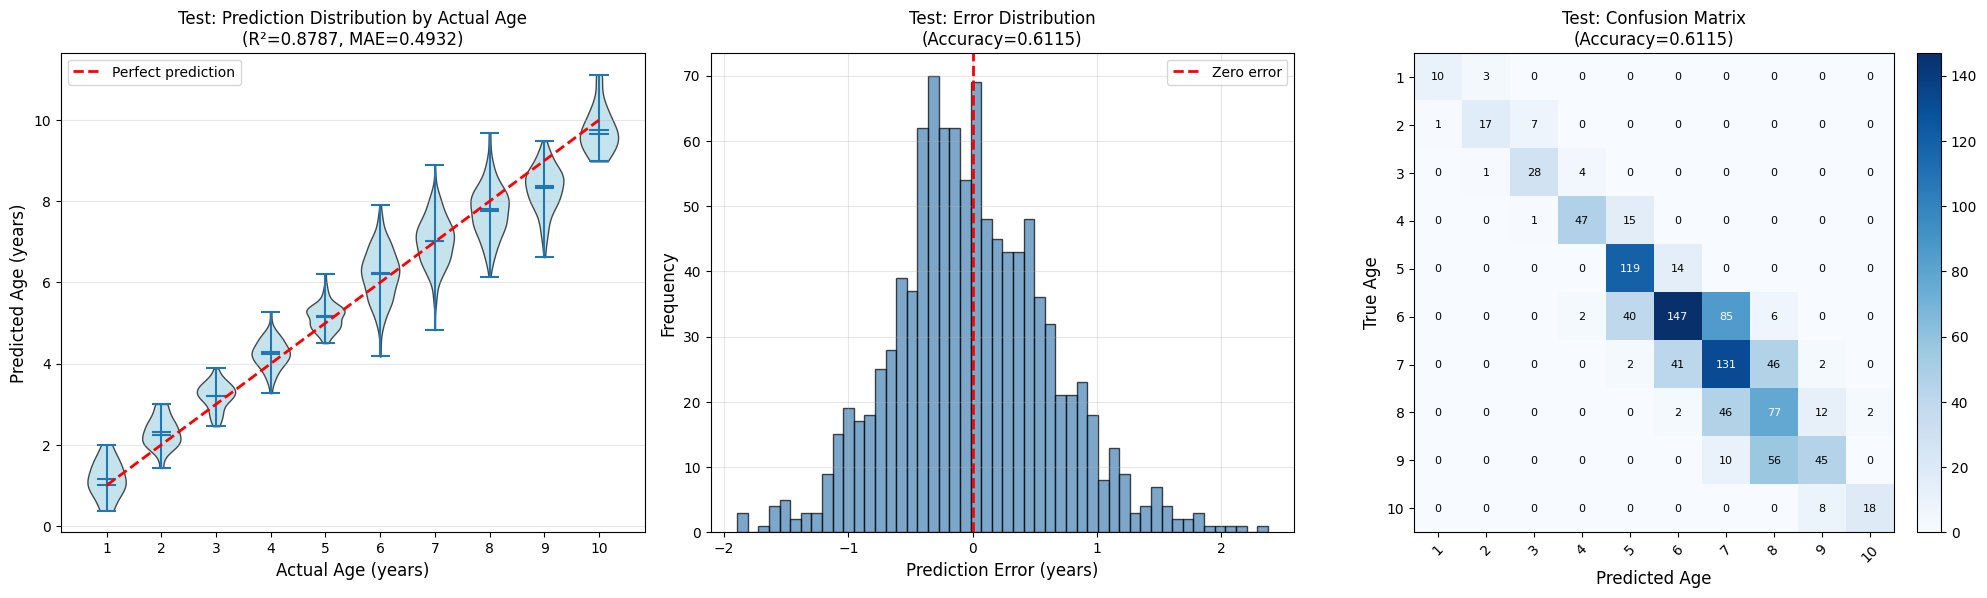


SUMMARY

Best alpha selected: 174.752840

Test Performance:
  R²: 0.8787 (explains 87.87% of variance)
  RMSE: 0.6314 years
  MAE: 0.4932 years
  Exact Match Accuracy: 61.15%
  Within ±1 year: 97.51%


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix


# ========== PREDICTIONS ==========

y_test_pred = ridge.predict(X_test_scaled)
y_test_pred_class = np.clip(np.round(y_test_pred).astype(int), 1, 10)

# ========== REGRESSION METRICS ==========
print("\n" + "="*60)
print("REGRESSION METRICS (Continuous Predictions)")
print("="*60)

# Test metrics
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nTest Set:")
print(f"  R²: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.4f} years")
print(f"  MAE: {mae_test:.4f} years")

# ========== CLASSIFICATION METRICS ==========
print("\n" + "="*60)
print("CLASSIFICATION METRICS (Rounded Predictions)")
print("="*60)

# Within N years accuracy
def accuracy_within_n_years(y_true, y_pred, n):
    """Calculate percentage of predictions within n years of true age"""
    errors = np.abs(y_true - y_pred)
    return np.mean(errors <= n)


# Test accuracy
acc_test = accuracy_score(y_test, y_test_pred_class)
print(f"\nTest Set:")
print(f"  Exact Match Accuracy: {acc_test:.4f} ({acc_test*100:.2f}%)")

print(f"\n  Accuracy within N years:")
for n in range(0, 4):
    if n == 0:
        acc = acc_test
    else:
        acc = accuracy_within_n_years(y_test, y_test_pred_class, n)
    print(f"    ±{n} years: {acc:.4f} ({acc*100:.2f}%)")

# ========== DETAILED CLASSIFICATION REPORT ==========
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_test_pred_class))

# ========== CONFUSION MATRIX ==========
print("="*60)
print("CONFUSION MATRIX (Test Set)")
print("="*60)
cm = confusion_matrix(y_test, y_test_pred_class)
print(cm)

# ========== VISUALIZATIONS ==========
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Violin Plot: Predicted Age Distribution by Actual Age
# Prepare data for violin plot
import pandas as pd
plot_df = pd.DataFrame({
    'Actual Age': y_test,
    'Predicted Age': y_test_pred
})

# Create violin plot
unique_ages = sorted(plot_df['Actual Age'].unique())
positions = range(len(unique_ages))
violin_data = [plot_df[plot_df['Actual Age'] == age]['Predicted Age'].values 
               for age in unique_ages]

parts = axes[0].violinplot(violin_data, positions=positions, widths=0.7,
                            showmeans=True, showmedians=True)

# Customize violin plot colors
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

# Add perfect prediction line
axes[0].plot(positions, unique_ages, 'r--', lw=2, label='Perfect prediction', zorder=10)

axes[0].set_xlabel('Actual Age (years)', fontsize=12)
axes[0].set_ylabel('Predicted Age (years)', fontsize=12)
axes[0].set_title(f'Test: Prediction Distribution by Actual Age\n(R²={r2_test:.4f}, MAE={mae_test:.4f})', 
                  fontsize=12)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(unique_ages)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Error Distribution
residuals_test = y_test - y_test_pred
axes[1].hist(residuals_test, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero error')
axes[1].set_xlabel('Prediction Error (years)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Test: Error Distribution\n(Accuracy={acc_test:.4f})', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap with numbers
im = axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
axes[2].set_title(f'Test: Confusion Matrix\n(Accuracy={acc_test:.4f})', fontsize=12)
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

# Get unique ages for ticks
unique_ages_cm = np.unique(np.concatenate([y_test, y_test_pred_class]))
tick_marks = np.arange(len(unique_ages_cm))

axes[2].set_xticks(tick_marks)
axes[2].set_yticks(tick_marks)
axes[2].set_xticklabels(unique_ages_cm, rotation=45)
axes[2].set_yticklabels(unique_ages_cm)
axes[2].set_ylabel('True Age', fontsize=12)
axes[2].set_xlabel('Predicted Age', fontsize=12)

# Add text annotations to confusion matrix
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=8)

plt.tight_layout()
plt.show()

# ========== SUMMARY ==========
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\nBest alpha selected: {ridge.alpha_:.6f}")

print(f"\nTest Performance:")
print(f"  R²: {r2_test:.4f} (explains {r2_test*100:.2f}% of variance)")
print(f"  RMSE: {rmse_test:.4f} years")
print(f"  MAE: {mae_test:.4f} years")
print(f"  Exact Match Accuracy: {acc_test*100:.2f}%")
print(f"  Within ±1 year: {accuracy_within_n_years(y_test, y_test_pred_class, 1)*100:.2f}%")

## Weighted Model

In [16]:
data = np.load("../../outputs/embeddings/siglip2-so400m-14-384_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

columns = ["length","quarter_2","quarter_3","quarter_4"]
metadata_csv = "../../cod_otolith_age_final_with_quarters.csv"

features = augment_embeddings(
                features, measurements_ids, metadata_csv, columns
            )

# Create weights instead of filtering
weights = np.ones(len(measurements_ids))

# Get flagged samples from df
df_filter = df[df["confidence_in_given"] <= 1]  # Adjust this threshold if needed
flagged_mask = np.isin(measurements_ids, df_filter["measurement_id"])

# Assign confidence scores as weights for flagged samples
for idx in np.where(flagged_mask)[0]:
    measurement_id = measurements_ids[idx]
    conf = df[df["measurement_id"] == measurement_id]["confidence_in_given"].values[0]
    weights[idx] = conf

rs = 77

# Split with ALL data (no filtering)
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    features, labels, weights, 
    test_size=0.15, 
    stratify=labels, 
    random_state=rs
)

print(f"Train set dimension: {len(X_train)}")
print(f"Test set dimension: {len(X_test)}")
print(f"Flagged samples in train: {(weights_train < 1.0).sum()}")
print(f"Mean weight in train: {weights_train.mean():.3f}")
print(f"Min weight in train: {weights_train.min():.3f}")

print("="*60)
print("SCALING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"Scaled feature shape: {X_train_scaled.shape}")
print(f"Scaler fit on {X_train.shape[0]} samples")

Train set dimension: 7341
Test set dimension: 1296
Flagged samples in train: 1418
Mean weight in train: 0.856
Min weight in train: 0.000
SCALING FEATURES
Original feature shape: (7341, 1156)
Scaled feature shape: (7341, 1156)
Scaler fit on 7341 samples


In [18]:
# ========== TRAINING ==========

alphas = np.logspace(1.5, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5) 

# Fit with sample weights
ridge.fit(X_train_scaled, y_train, sample_weight=weights_train)

print(f"Best alpha: {ridge.alpha_:.6f}")
print(f"Tested {len(alphas)} alpha values from {alphas.min():.4f} to {alphas.max():.4f}")
print(f"Effective training samples: {weights_train.sum():.1f} (vs {len(weights_train)} actual)")

Best alpha: 84.834290
Tested 50 alpha values from 31.6228 to 1000.0000
Effective training samples: 6281.2 (vs 7341 actual)


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix


# ========== PREDICTIONS ==========

y_test_pred = ridge.predict(X_test_scaled)
y_test_pred_class = np.clip(np.round(y_test_pred).astype(int), 1, 10)

# ========== REGRESSION METRICS ==========
print("\n" + "="*60)
print("REGRESSION METRICS (Continuous Predictions)")
print("="*60)

# Test metrics
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nTest Set:")
print(f"  R²: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.4f} years")
print(f"  MAE: {mae_test:.4f} years")

# ========== CLASSIFICATION METRICS ==========
print("\n" + "="*60)
print("CLASSIFICATION METRICS (Rounded Predictions)")
print("="*60)

# Within N years accuracy
def accuracy_within_n_years(y_true, y_pred, n):
    """Calculate percentage of predictions within n years of true age"""
    errors = np.abs(y_true - y_pred)
    return np.mean(errors <= n)

# Test accuracy
acc_test = accuracy_score(y_test, y_test_pred_class)
print(f"\nTest Set:")
print(f"  Exact Match Accuracy: {acc_test:.4f} ({acc_test*100:.2f}%)")

print(f"\n  Accuracy within N years:")
for n in range(0, 4):
    if n == 0:
        acc = acc_test
    else:
        acc = accuracy_within_n_years(y_test, y_test_pred_class, n)
    print(f"    ±{n} years: {acc:.4f} ({acc*100:.2f}%)")




REGRESSION METRICS (Continuous Predictions)

Test Set:
  R²: 0.8557
  RMSE: 0.7367 years
  MAE: 0.5761 years

CLASSIFICATION METRICS (Rounded Predictions)

Test Set:
  Exact Match Accuracy: 0.5316 (53.16%)

  Accuracy within N years:
    ±0 years: 0.5316 (53.16%)
    ±1 years: 0.9506 (95.06%)
    ±2 years: 0.9977 (99.77%)
    ±3 years: 1.0000 (100.00%)


### Learning Curve

In [20]:
import random
random.seed(42)

seeds = [random.randint(1, 100) for _ in range(0, 5)]
train_props = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.]

performance = {seed: {} for seed in seeds}

alphas = np.logspace(1.5, 3, 50)

for seed in seeds: 

    performance[seed] = {}

    X_train, X_test, y_train, y_test = train_test_split(
        feat_clean, 
        labels_clean, 
        test_size=0.15, 
        stratify=labels_clean, 
        random_state = seed
        )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(X_train.shape)
    
    for prop in train_props:
        #X_train
        n_samples = int(prop * X_train.shape[0])
        X_train_scaled_sl, y_train_sl = X_train_scaled[:n_samples,:], y_train[:n_samples]

        ridge = RidgeCV(alphas=alphas, cv=5) 
        ridge.fit(X_train_scaled_sl, y_train_sl)

        # ========== PREDICTIONS ==========

        y_test_pred = ridge.predict(X_test_scaled)
        y_test_pred_class = np.clip(np.round(y_test_pred).astype(int), 1, 10)
        # Accuracy
        acc_test = accuracy_score(y_test, y_test_pred_class)

        performance[seed][prop] = {
            "accuracy": acc_test,
            "n_samples": n_samples,
            "best_alpha": ridge.alpha_
        }

        



          

        


(5917, 1156)
(5917, 1156)
(5917, 1156)
(5917, 1156)
(5917, 1156)


In [139]:
performance


{82: {0.2: {'accuracy': 0.533715925394548,
   'n_samples': 1253,
   'best_alpha': 171.66979066078602},
  0.4: {'accuracy': 0.5824964131994261,
   'n_samples': 2506,
   'best_alpha': 171.66979066078602},
  0.6: {'accuracy': 0.5810616929698709,
   'n_samples': 3759,
   'best_alpha': 149.09716571840644},
  0.8: {'accuracy': 0.5882352941176471,
   'n_samples': 5012,
   'best_alpha': 159.98587196060572},
  1.0: {'accuracy': 0.599713055954089,
   'n_samples': 6265,
   'best_alpha': 184.20699693267164}},
 15: {0.2: {'accuracy': 0.5509325681492109,
   'n_samples': 1253,
   'best_alpha': 149.09716571840644},
  0.4: {'accuracy': 0.5753228120516499,
   'n_samples': 2506,
   'best_alpha': 159.98587196060572},
  0.6: {'accuracy': 0.5925394548063128,
   'n_samples': 3759,
   'best_alpha': 159.98587196060572},
  0.8: {'accuracy': 0.6183644189383071,
   'n_samples': 5012,
   'best_alpha': 171.66979066078602},
  1.0: {'accuracy': 0.6140602582496413,
   'n_samples': 6265,
   'best_alpha': 184.2069969326

In [115]:
accuracies_by_prop

mean_acc = np.mean([d["accuracy"] for d in accuracies_by_prop[prop]])
mean_acc

X_train.shape

(6265, 1156)

In [ ]:
# Extract data into arrays
train_props = [.1, .2, .3, .4, .5 ,.6, .7, .8, .9, 1.] 
seeds = list(performance.keys())

# Collect accuracies for each proportion
accuracies_by_prop = {prop: [] for prop in train_props}

for seed in seedss:
    for prop in train_props:
        acc = performance[seed][prop]
        accuracies_by_prop[prop].append(acc)

perf_acc = []
perf_std = []

# Calculate training length
train_dim = [int(p * X_train.shape[0]) for p in train_props]

# Calculate mean and std for each proportion
for prop in train_props: 
    mean_acc = np.mean([d["accuracy"] for d in accuracies_by_prop[prop]])
    std_acc = np.std([d["accuracy"] for d in accuracies_by_prop[prop]]) 

    perf_acc.append(mean_acc)
    perf_std.append(std_acc)



# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_dim, perf_acc, 'o-', linewidth=2, markersize=8, label='Mean accuracy')
plt.fill_between(train_dim, 
                 np.array(perf_acc) - np.array(perf_std),
                 np.array(perf_acc) + np.array(perf_std),
                 alpha=0.2, label='±1 std')

plt.xlabel('Training set size', fontsize=12)
plt.ylabel('Test accuracy', fontsize=12)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary
print("Training Size | Mean Accuracy | Std Dev")
print("-" * 45)
for prop, n_samples in zip(train_props, train_dim):
    mean = np.mean(accuracies_by_prop[prop])
    std = np.std(accuracies_by_prop[prop])
    print(f"{n_samples:>13} | {mean:>13.4f} | {std:>7.4f}")

    

NameError: name 'performance' is not defined

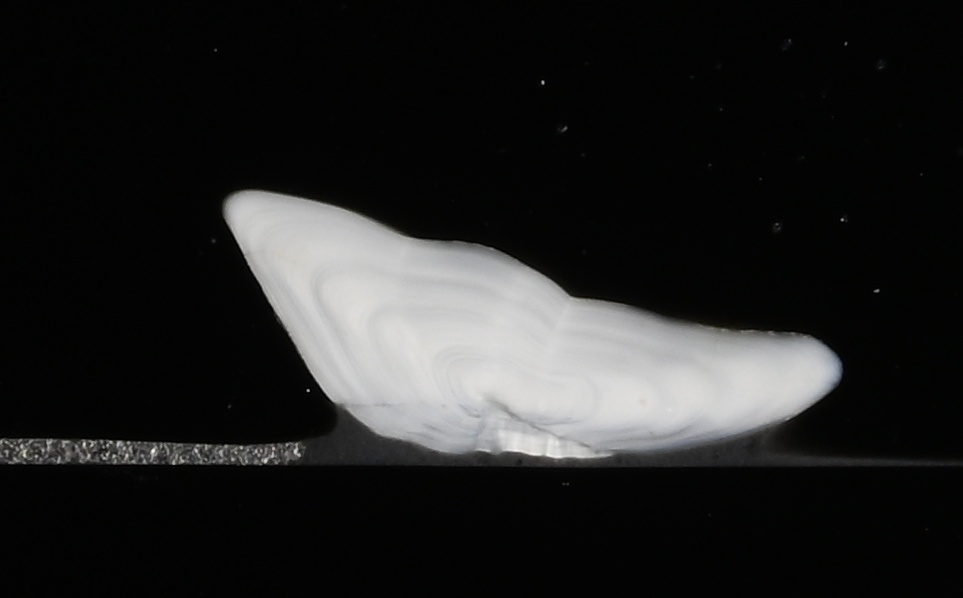

In [91]:
img=Image.open("../otolith_images/4/23709655.jpg")

img

### Same confidence and label

In [63]:
df

,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested,confidence_given_minus_sugg,given_minus_sugg_label
0,175,24409454,10,5,8.031457e-12,0.564128,0.564128,-5
1,2189,24601200,5,9,1.932301e-08,0.562265,0.562265,4
2,1241,24319685,4,8,2.427852e-08,0.556369,0.556369,4
3,2021,24319683,5,8,3.493361e-06,0.455733,0.455729,3
4,363,24601328,10,7,9.872978e-06,0.512644,0.512635,-3
...,...,...,...,...,...,...,...,...
1814,267,24727483,10,9,4.634575e-01,0.470652,0.007194,-1
1821,278,24719424,10,9,4.644137e-01,0.470014,0.005600,-1
1825,451,24316234,10,9,4.646442e-01,0.469860,0.005215,-1
1845,336,23894714,10,9,4.665105e-01,0.468610,0.002099,-1
